1.- Recortar el punto de interes de la imagen tal cual se muestra en la figura, guardar la imagen recortsda en tu disco, y muestra la imagen original y la recortada con axis imagen a colores 

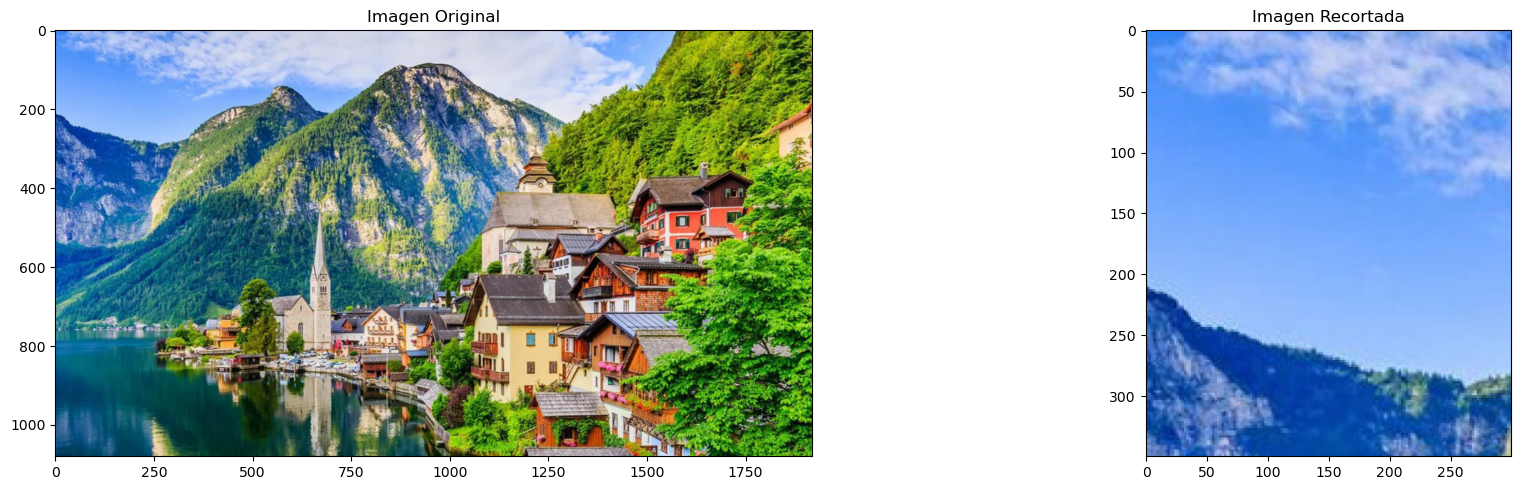

In [35]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img= cv2.imread('img1.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(20, 5))
axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')
axs[1].imshow(img_rgb[:350,:300,:])
axs[1].set_title('Imagen Recortada')

plt.tight_layout()
plt.show()

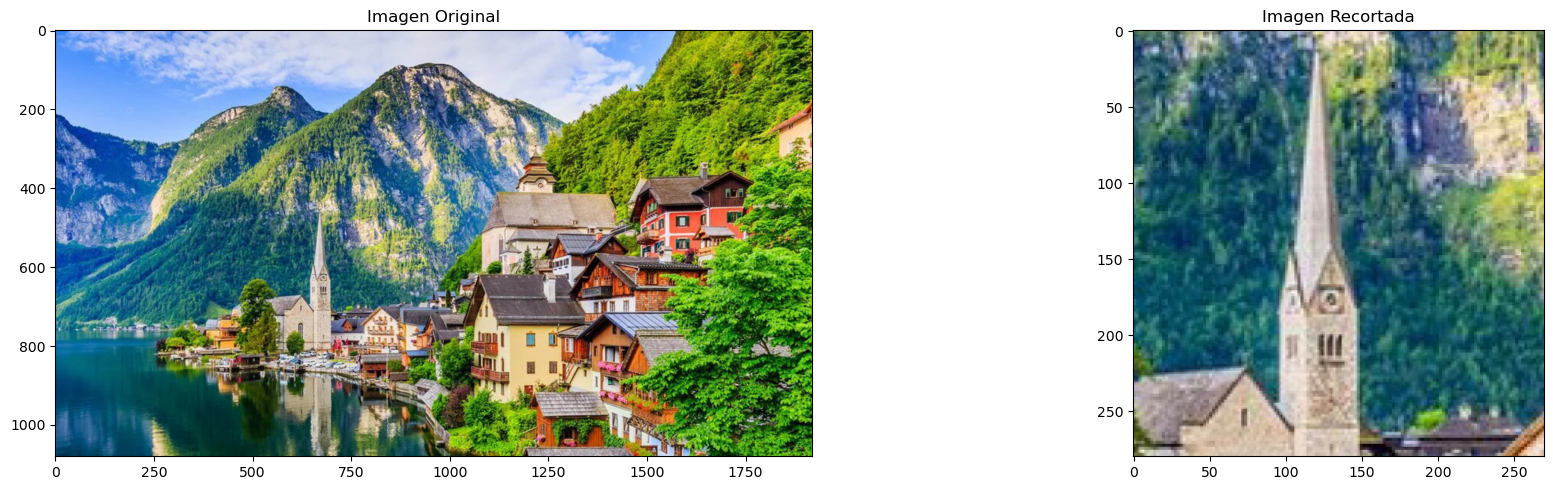

In [66]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('img1.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

recorte = img_rgb[450:730, 550:820, :]



fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')

axs[1].imshow(recorte)
axs[1].set_title('Imagen Recortada')

plt.tight_layout()
plt.show()


cv2.imwrite('imagen.jpg', cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))
plt.imsave('imagen_nueva3.jpg', recorte)


2.- Genera un degrade lineal a olores 

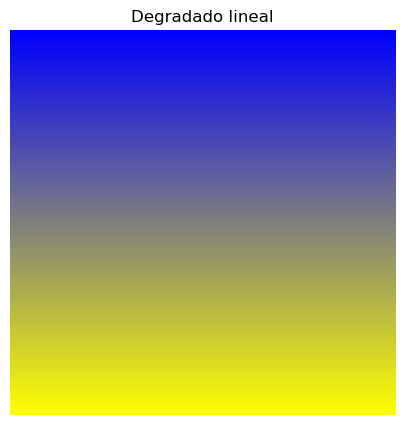

In [88]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [10, 5]

size_imagen = 200

# degrade vertical de arriba hacia abajo
grad = np.linspace(0, 1, size_imagen)
grad = np.tile(grad.reshape(size_imagen, 1), (1, size_imagen))

# Canales
R = 255 * grad                      
G = 255 * grad                      
B = 255 * (1 - grad)               

imagen = np.dstack((R, G, B))
imagen = np.array(imagen, dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('Degradado lineal')
plt.axis('off')
plt.show()


3.- Genera una imagen semeh=jante a un tablero de ajedrez tomando  en cuenta que cada casila debe de medir 100x100 px

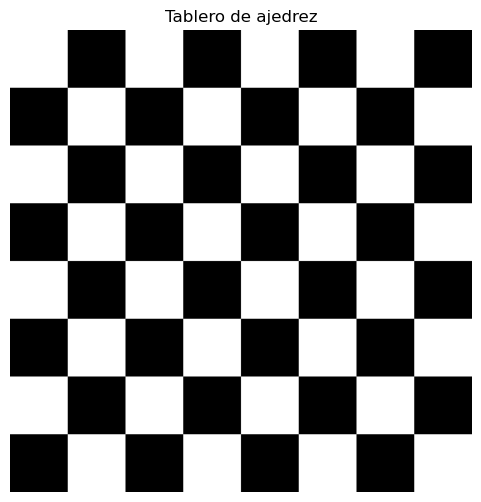

In [79]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6, 6]

size = 800          # 8x8 bloques de 100x100
n = 8               # tablero 
bloque = 100        # cada casilla 100x100

R = np.zeros((size, size))
G = np.zeros((size, size))
B = np.zeros((size, size))

# doble ciclo para llenar cada bloque con el color correspondiente
for i in range(n):
    for j in range(n):

        r0 = i * bloque
        r1 = (i + 1) * bloque
        c0 = j * bloque
        c1 = (j + 1) * bloque

        # codigo para obtener el color de cada bloque
        if (i + j) % 2 == 0:
            rv, gv, bv = 255, 255, 255   # bl
        else:
            rv, gv, bv = 0, 0, 0         # n

        R[r0:r1, c0:c1] = rv
        G[r0:r1, c0:c1] = gv
        B[r0:r1, c0:c1] = bv

imagen = np.dstack((R, G, B)).astype(np.uint8)

plt.imshow(imagen)
plt.title("Tablero de ajedrez")
plt.axis("off")
plt.show()


4.- Basandonos en el resultado del ejercicio 2 aplica posterizacion y solarizacion de la misma manera aplica todas las plaetas de falso color cada resultado debe gusrdarse 

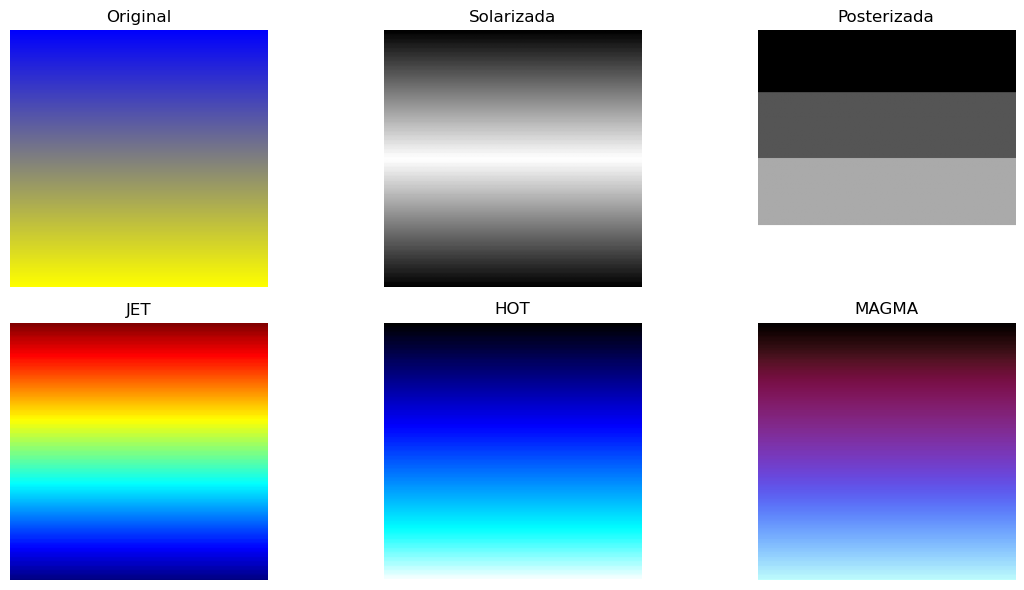

True

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]

size_imagen = 200

grad = np.linspace(0, 1, size_imagen)
grad = np.tile(grad.reshape(size_imagen, 1), (1, size_imagen))

R = 255 * grad
G = 255 * grad
B = 255 * (1 - grad)

imagen = np.dstack((R, G, B)).astype(np.uint8)

#funciones de posterizacion y solarizacion mas el de falso color
def solarizar(imagen, umbral):
    return np.where(imagen < umbral, imagen, 255 - imagen)

def posterizar(imagen, niveles):
    factor = 256 // niveles
    return (np.round(imagen / factor) * factor).astype(np.uint8)

def falso_color(img_gray, mapa):
    escala = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.applyColorMap(escala, mapa)

#converitr a gray
img_gray = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

# aplicamos solarizacion y posterizacion
img_solar = solarizar(img_gray, 128)
img_post = posterizar(img_gray, 5)

# falso color con varias paletas
fc_jet = falso_color(img_gray, cv2.COLORMAP_JET)
fc_hot = falso_color(img_gray, cv2.COLORMAP_HOT)
fc_magma = falso_color(img_gray, cv2.COLORMAP_MAGMA)
fc_plasma = falso_color(img_gray, cv2.COLORMAP_PLASMA)

# visualizamos todo
plt.figure(figsize=(12,6))

plt.subplot(231)
plt.title("Original")
plt.imshow(imagen)
plt.axis('off')

plt.subplot(232)
plt.title("Solarizada")
plt.imshow(img_solar, cmap='gray')
plt.axis('off')

plt.subplot(233)
plt.title("Posterizada")
plt.imshow(img_post, cmap='gray')
plt.axis('off')

plt.subplot(234)
plt.title("JET")
plt.imshow(fc_jet)
plt.axis('off')

plt.subplot(235)
plt.title("HOT")
plt.imshow(fc_hot)
plt.axis('off')

plt.subplot(236)
plt.title("MAGMA")
plt.imshow(fc_magma)
plt.axis('off')

plt.tight_layout()
plt.show()

#guardamos
cv2.imwrite("original.png", cv2.cvtColor(imagen, cv2.COLOR_RGB2BGR))
cv2.imwrite("solarizada.png", img_solar)
cv2.imwrite("posterizada.png", img_post)
cv2.imwrite("falso_color_jet.png", fc_jet)
cv2.imwrite("falso_color_hot.png", fc_hot)
cv2.imwrite("falso_color_magma.png", fc_magma)
cv2.imwrite("falso_color_plasma.png", fc_plasma)


5.- Tomando en cuenta la imagen aplicar degrade lineal en ella

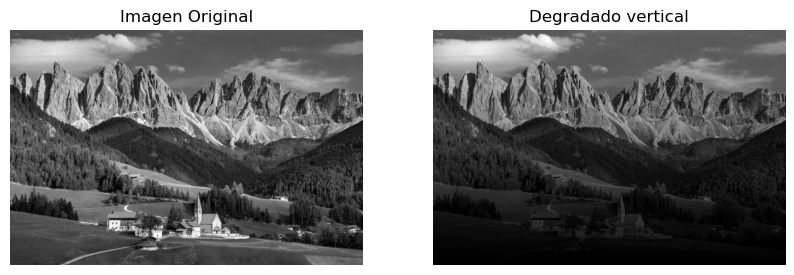

In [86]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('img2.jpeg', cv2.IMREAD_GRAYSCALE)

# degrade lineal vertical
filas, columnas = img.shape

grad = np.linspace(1, 0, filas)  # abajo , arriba
grad = np.tile(grad.reshape(filas, 1), (1, columnas))

# aplicamos el degradado 
img_degradada = (img * grad).astype(np.uint8)

# mostramos
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_degradada, cmap='gray')
plt.title('Degradado vertical')
plt.axis('off')

plt.show()


6.- Practica creativa

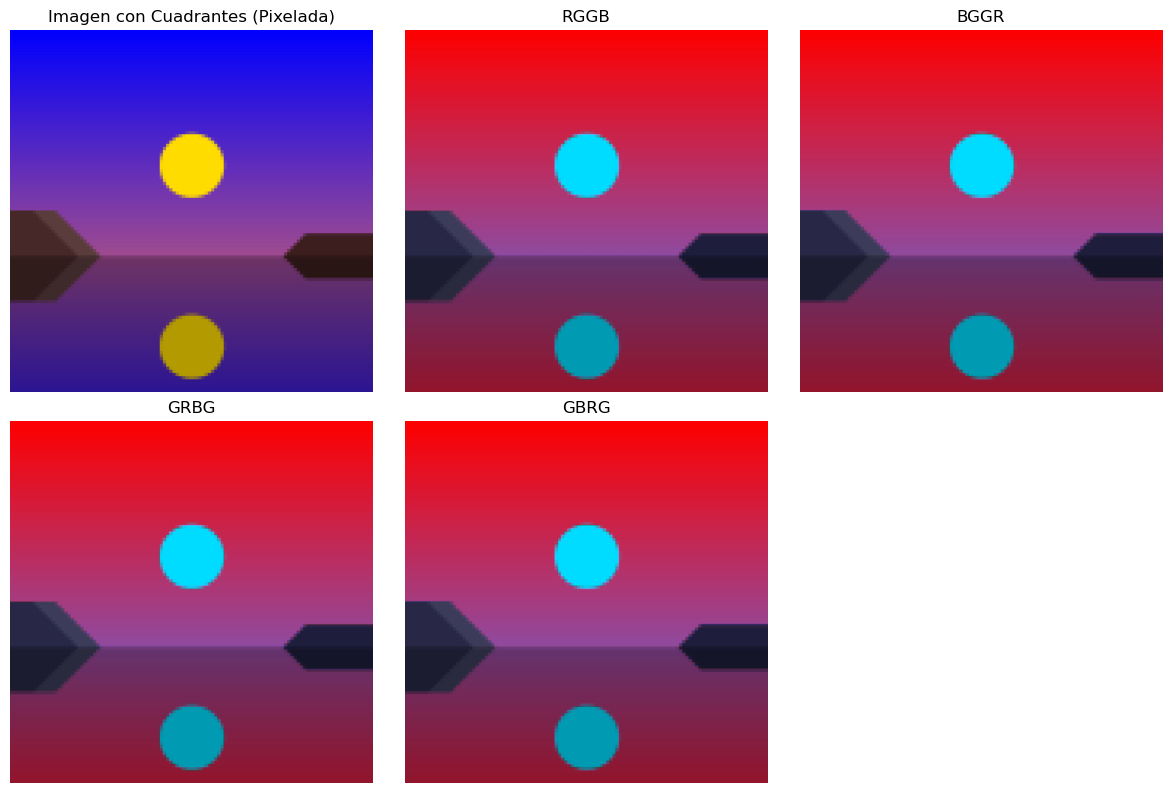

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# img creada
tam = 800
img = np.zeros((tam, tam, 3), dtype=np.uint8)

# cielo
filas = np.linspace(0, 1, tam).reshape(tam, 1)
R = (255 * filas).astype(np.uint8)
G = (120 * filas).astype(np.uint8)
B = (255 * (1 - filas * 0.7)).astype(np.uint8)

img[:] = np.dstack((B, G, R))

# sol
Y, X = np.ogrid[:tam, :tam]
cx, cy = 400, 300
radio2 = 5000

mask_sol = (X - cx)**2 + (Y - cy)**2 < radio2
img[mask_sol] = (0, 220, 255)

# cerros
zona = (Y >= 400) & (Y < 650)
mask1 = zona & (X < Y - 300)
mask2 = zona & (X < Y - 350)

img[mask1] = (60, 60, 90)
img[mask2] = (40, 40, 70)

zona2 = (Y >= 450) & (Y < 700)
mask3 = zona2 & (X > tam - (Y - 300))
img[mask3] = (30, 30, 60)

# reflejo
mitad = 500
altura_reflejo = tam - mitad
reflejo = img[mitad - altura_reflejo:mitad][::-1] * 0.7
img[mitad:] = reflejo.astype(np.uint8)

bloque = 7 #tmn pixel

h, w = img.shape[:2]

# reducir solucion
img_small = cv2.resize(img, (w // bloque, h // bloque), interpolation=cv2.INTER_AREA)

# volver a esc
img_pixel = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_NEAREST)

# bayer sin for
def crear_bayer_fast(imagen, patron):
    B, G, R = cv2.split(imagen)
    mosaico = np.zeros(imagen.shape[:2], dtype=np.uint8)

    if patron == "RGGB":
        mosaico[0::2, 0::2] = R[0::2, 0::2]
        mosaico[0::2, 1::2] = G[0::2, 1::2]
        mosaico[1::2, 0::2] = G[1::2, 0::2]
        mosaico[1::2, 1::2] = B[1::2, 1::2]

    elif patron == "BGGR":
        mosaico[0::2, 0::2] = B[0::2, 0::2]
        mosaico[0::2, 1::2] = G[0::2, 1::2]
        mosaico[1::2, 0::2] = G[1::2, 0::2]
        mosaico[1::2, 1::2] = R[1::2, 1::2]

    elif patron == "GRBG":
        mosaico[0::2, 0::2] = G[0::2, 0::2]
        mosaico[0::2, 1::2] = R[0::2, 1::2]
        mosaico[1::2, 0::2] = B[1::2, 0::2]
        mosaico[1::2, 1::2] = G[1::2, 1::2]

    elif patron == "GBRG":
        mosaico[0::2, 0::2] = G[0::2, 0::2]
        mosaico[0::2, 1::2] = B[0::2, 1::2]
        mosaico[1::2, 0::2] = R[1::2, 0::2]
        mosaico[1::2, 1::2] = G[1::2, 1::2]

    return mosaico

def reconstruir(mosaico, patron):
    codigos = {
        "RGGB": cv2.COLOR_BAYER_RG2BGR,
        "BGGR": cv2.COLOR_BAYER_BG2BGR,
        "GRBG": cv2.COLOR_BAYER_GR2BGR,
        "GBRG": cv2.COLOR_BAYER_GB2BGR
    }
    return cv2.cvtColor(mosaico, codigos[patron])

# mostrams img
patrones = ["RGGB", "BGGR", "GRBG", "GBRG"]

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img_pixel, cv2.COLOR_BGR2RGB))
plt.title("Imagen con Cuadrantes (Pixelada)")
plt.axis("off")

for i, p in enumerate(patrones):
    mosaico = crear_bayer_fast(img_pixel, p)
    rec = reconstruir(mosaico, p)

    plt.subplot(2,3,i+2)
    plt.imshow(cv2.cvtColor(rec, cv2.COLOR_BGR2RGB))
    plt.title(p)
    plt.axis("off")

plt.tight_layout()
plt.show()
